# Value Iteration

## Learning Objectives

By the end of this notebook, you will be able to:
- explain how value iteration updates state values directly
- implement the Bellman optimality update in a small MDP
- extract a greedy policy from the final value table
- understand why value iteration is different from policy iteration

## Prerequisites

Before starting:
- complete `02_mdp_solving.ipynb`
- understand states, actions, rewards, and terminal states
- know the difference between a policy and a value function


## Lesson Brief

This lesson focuses on **value iteration**, one of the clearest ways to compute an optimal policy in a small MDP.

Students will learn how repeated Bellman updates gradually improve value estimates until the best action becomes clear in each state.

Why this matters: value iteration gives students a concrete bridge between theory and computation.

It also prepares them to understand why later RL methods approximate values instead of calculating them exactly.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can jump back to re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.

## Recommended YouTube Video

To reinforce this lesson, watch **Computerphile - "Solve Markov Decision Processes with the Value Iteration Algorithm"**:
[Watch on YouTube](https://www.youtube.com/watch?v=dZ0SQrr4g8g)

Why this pick:
- Helps students see how repeated Bellman updates lead to a usable policy.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Value: the long-term usefulness of a state.
- Bellman optimality update: update a state using the best available action return.
- Greedy action: the action with the highest current estimated return.
- Sweep: one full pass that updates every non-terminal state once using the Bellman optimality backup. In this notebook the pass is **synchronous**: while computing the sweep, every state reads from the value table frozen at the *start* of that sweep, then all new values are written at the end. That is why distant rewards usually need **many sweeps** to propagate through the grid—each sweep typically carries the signal about one step farther.
- Convergence: when repeated sweeps change the values only a tiny amount.
- Discount factor `gamma`: how strongly future rewards influence the update.

### Quick Check
- Why do values improve through repeated sweeps instead of one pass only?
- Why do we take a `max` over actions in value iteration?
- What does `gamma` change in the update target?
- What sign shows the algorithm is stabilizing?

### Common Mistakes
- Thinking one update is enough.
- Choosing by immediate reward only.
- Confusing updated values with the final policy.
- Thinking `gamma` is just a technical constant instead of a long-term preference setting.


## Big idea

In policy iteration, you alternate between:
- evaluating a policy
- improving the policy

In **value iteration**, you skip full policy evaluation and update each state with the
best one-step action immediately.

This often makes value iteration simpler to teach and implement for small MDPs.

## Value Iteration vs Policy Iteration

Students often ask: if both methods can lead to a strong policy, why do we need value iteration at all?

### Policy iteration

Policy iteration separates the work into two phases:

1. evaluate the current policy
2. improve the policy

This is conceptually clean because the class can see the two jobs separately.

### Value iteration

Value iteration compresses that process.
Instead of fully evaluating one policy first, it updates each state using the
best one-step action immediately.

That is why the `max` appears inside the update rule.

### Why does `gamma` matter here?

In value iteration, the target is not just the immediate reward.
It is:

- reward now
- plus discounted future value from the next state

So `gamma` controls how much the algorithm cares about consequences beyond the current move.

- lower `gamma` -> more short-term behavior
- higher `gamma` -> more long-term behavior

### Practical intuition

If the goal is a few steps away, a high enough `gamma` lets that future reward
"flow backward" through the earlier states over repeated sweeps.

That backward flow of useful future value is the main reason value iteration works.

## Checkpoint Before Coding

Make sure you can explain these before continuing:

1. Why does the value of a state depend on the *next* state?
2. Why do we use `max` over actions in value iteration?
3. What should happen to terminal states during updates?

If these feel unclear, review the summary of `02_mdp_solving.ipynb` first.


### Step Guide

**What this cell does:** Builds the tiny grid world (states, actions, rewards) and helper functions you will reuse below.

**How to read it (weak Python OK):** Scroll slowly. After each `print(...)`, stop and check: *which number is bigger/smaller and why might that be true in the story of the grid?*

**What to expect in the output:** Text grids, a few numbers, and maybe a small check that a transition works.

**If you feel lost:** Ignore “clever” Python for now. Circle three names only: `values`, `policy`, and `transition`—those are the spine of the lesson.


In [1]:
# -----------------------------------------------------------------------------
# CELL: Environment, grid MDP, helpers
# This cell defines the toy world and small utilities used later.
# Each block below has a header, then the Python it explains.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BLOCK: Imports and print options
# NumPy: arrays for V(s). Matplotlib: figures for values/policy/convergence.
# -----------------------------------------------------------------------------
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.set_printoptions(precision=2, suppress=True)

# -----------------------------------------------------------------------------
# BLOCK: Console banner
# Optional separator so notebook output is easy to spot while teaching.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("=" * 70)
# Show text or numbers in the cell output area under the code.
print("Value Iteration in a Small Grid World")
# Show text or numbers in the cell output area under the code.
print("=" * 70)

# -----------------------------------------------------------------------------
# BLOCK: MDP constants (states, actions, terminals, discount)
# States 0..8 row-major. Actions 0..3. Terminals are absorbing in transition().
# GAMMA is the discount factor inside every Bellman target r + gamma * V(s').
# -----------------------------------------------------------------------------
# Set grid height and width in cells (3x3 in this toy MDP).
N_ROWS, N_COLS = 3, 3
# Total number of states = rows * columns (flattened indices 0..N-1).
N_STATES = N_ROWS * N_COLS
# Create the list of action names (their indices are the numeric action ids).
ACTIONS = ["up", "right", "down", "left"]

# Save a value in a name so the next lines can read it.
ACTION_TO_DELTA = {
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    0: (-1, 0),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    1: (0, 1),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    2: (1, 0),
    # One entry in ACTION_TO_DELTA: maps an action id to a (d_row, d_col) move on the grid.
    # Dictionary/map entry: this key maps to the tuple/value on the right.
    3: (0, -1),
# Part of a dict/set literal layout (syntax grouping).
}
# Map each action id to a Unicode arrow symbol for policy printing/plotting.
ACTION_TO_ARROW = {0: "↑", 1: "→", 2: "↓", 3: "←"}

# Pick which flat state ids are special terminals for rewards in transition().
GOAL_STATE = 8
# Pick which flat state ids are special terminals for rewards in transition().
PIT_STATE = 6
# Build the set of terminal state ids (used to skip Bellman backups).
TERMINAL_STATES = {GOAL_STATE, PIT_STATE}
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA = 0.90

# -----------------------------------------------------------------------------
# FUNCTION: to_pos(state) -> (row, col)
# Flat index -> grid coordinates for this row-major layout.
# -----------------------------------------------------------------------------
# Function `to_pos` (what it does): Map flat state id to (row, col) on the N_ROWS x N_COLS grid.
def to_pos(state):
    """Map flat state id to (row, col) on the N_ROWS x N_COLS grid."""
    # Send a value back to whoever called this function.
    return divmod(state, N_COLS)

# -----------------------------------------------------------------------------
# FUNCTION: to_state(row, col) -> state_id
# Inverse of to_pos: grid coordinates -> flat index used by V[state].
# -----------------------------------------------------------------------------
# Function `to_state` (what it does): Map (row, col) to a flat state index used by V[state].
def to_state(row, col):
    """Map (row, col) to a flat state index used by V[state]."""
    # Send a value back to whoever called this function.
    return row * N_COLS + col

# -----------------------------------------------------------------------------
# FUNCTION: transition(state, action) -> (next_state, reward)
# Known model for backups: clamp moves to the grid, then apply goal/pit/step rewards.
# -----------------------------------------------------------------------------
# Function `transition` (what it does): One-step dynamics: return (next_state, reward); terminals absorb with reward 0 here.
def transition(state, action):
    """One-step dynamics: return (next_state, reward); terminals absorb with reward 0 here."""
    # If the condition is True, run the indented block under this line.
    if state in TERMINAL_STATES:
        # Send a value back to whoever called this function.
        return state, 0.0

    # Save a value in a name so the next lines can read it.
    row, col = to_pos(state)
    # Another assignment—same idea: store a value for the lines below.
    d_row, d_col = ACTION_TO_DELTA[action]
    # Another assignment—same idea: store a value for the lines below.
    next_row = min(max(row + d_row, 0), N_ROWS - 1)
    # Another assignment—same idea: store a value for the lines below.
    next_col = min(max(col + d_col, 0), N_COLS - 1)
    # Unpack the one-step model output from transition(state, action).
    next_state = to_state(next_row, next_col)

    # If the condition is True, run the indented block under this line.
    if next_state == GOAL_STATE:
        # Send a value back to whoever called this function.
        return next_state, 10.0
    # If the condition is True, run the indented block under this line.
    if next_state == PIT_STATE:
        # Send a value back to whoever called this function.
        return next_state, -10.0
    # Send a value back to whoever called this function.
    return next_state, -1.0

# -----------------------------------------------------------------------------
# FUNCTION: state_grid_from_values(values)
# Builds a 2D matrix for imshow; terminals stay NaN on the heatmap.
# -----------------------------------------------------------------------------
# Function `state_grid_from_values` (what it does): Reshape 1D V(s) in row-major order into an (N_ROWS, N_COLS) grid for imshow.
def state_grid_from_values(values):
    """Reshape 1D V(s) in row-major order into an (N_ROWS, N_COLS) grid for imshow."""
    # Create the 2D array backing the value heatmap (NaN marks unused cells).
    grid = np.full((N_ROWS, N_COLS), np.nan)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # Create the 2D array backing the value heatmap (NaN marks unused cells).
        grid[r, c] = values[state]
    # Send a value back to whoever called this function.
    return grid

# -----------------------------------------------------------------------------
# FUNCTION: plot_values_and_policy(values, policy, title)
# Two panels: values heatmap + greedy arrows decoded from policy[state].
# -----------------------------------------------------------------------------
# Function `plot_values_and_policy` (what it does): Plot value heatmap and greedy policy arrows side by side with a shared title.
def plot_values_and_policy(values, policy, title):
    """Plot value heatmap and greedy policy arrows side by side with a shared title."""
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Convert the 1D value vector into a 2D layout suitable for imshow().
    value_grid = state_grid_from_values(values)
    # Capture the AxesImage object returned by imshow (used for the colorbar).
    im = axes[0].imshow(value_grid, cmap="viridis")
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    axes[0].set_title(f"{title}: values")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[0].set_yticks(range(N_ROWS))
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            label = f"{values[state]:.1f}"
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        axes[0].text(c, r, label, ha="center", va="center", color="white")
    # Change something about the whole figure (not just one small subplot).
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_title(f"{title}: greedy policy")
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xlim(-0.5, N_COLS - 0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_ylim(N_ROWS - 0.5, -0.5)
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_xticks(range(N_COLS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].set_yticks(range(N_ROWS))
    # Same plot panel as the line above—one more small plotting tweak.
    axes[1].grid(True)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # Save a value in a name so the next lines can read it.
        r, c = to_pos(state)
        # If the condition is True, run the indented block under this line.
        if state == GOAL_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "G"
        # Else-if: only checked when the earlier if/elif tests were False.
        elif state == PIT_STATE:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = "P"
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Choose what text to draw in this cell for goals/pits vs numeric values/arrows.
            symbol = ACTION_TO_ARROW[policy[state]]
        # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
        axes[1].text(c, r, symbol, ha="center", va="center", fontsize=13)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()

# -----------------------------------------------------------------------------
# FUNCTION: plot_deltas(deltas)
# X = sweep index, Y = largest Bellman change that sweep (shrinks as VI converges).
# -----------------------------------------------------------------------------
# Function `plot_deltas` (what it does): Plot per-sweep max Bellman change to visualize convergence speed.
def plot_deltas(deltas):
    """Plot per-sweep max Bellman change to visualize convergence speed."""
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.figure(figsize=(5, 3))
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(deltas, marker="o")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.title("Value iteration convergence")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.xlabel("Sweep number")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.ylabel("Largest Bellman update")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.grid(True, alpha=0.3)
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()

# -----------------------------------------------------------------------------
# FUNCTION: print_values(values)
# Text table of V(s) in grid layout; terminals print as G/P.
# -----------------------------------------------------------------------------
# Function `print_values` (what it does): Pretty-print the value table row by row in the notebook output.
def print_values(values):
    """Pretty-print the value table row by row in the notebook output."""
    # Show text or numbers in the cell output area under the code.
    print("\nState values:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  G   ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append("  P   ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f"{values[s]:6.2f}")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))

# -----------------------------------------------------------------------------
# FUNCTION: print_policy(policy)
# Text table of greedy arrows; policy[s] is an action index 0..3.
# -----------------------------------------------------------------------------
# Function `print_policy` (what it does): Pretty-print the greedy policy grid using arrows or digits.
def print_policy(policy):
    """Pretty-print the greedy policy grid using arrows or digits."""
    # Show text or numbers in the cell output area under the code.
    print("\nGreedy policy:")
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in range(N_ROWS):
        # Use a temporary list to format one printed row of the grid.
        row = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for c in range(N_COLS):
            # Convert (row, col) to the flat state id used by arrays like values[s].
            s = to_state(r, c)
            # If the condition is True, run the indented block under this line.
            if s == GOAL_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" G ")
            # Else-if: only checked when the earlier if/elif tests were False.
            elif s == PIT_STATE:
                # Add one new item to the end of a list (the list grows in place).
                row.append(" P ")
            # Else: run this block when none of the if/elif tests above matched.
            else:
                # Add one new item to the end of a list (the list grows in place).
                row.append(f" {ACTION_TO_ARROW[policy[s]]} ")
        # Show text or numbers in the cell output area under the code.
        print(" ".join(row))

# -----------------------------------------------------------------------------
# BLOCK: Sanity print (terminal ids)
# Confirms constants loaded; later cells assume these indices match transition().
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("Environment ready.")
# Show text or numbers in the cell output area under the code.
print("Goal state:", GOAL_STATE, "| Pit state:", PIT_STATE)


Value Iteration in a Small Grid World
Environment ready.
Goal state: 8 | Pit state: 6


## Part 1: One Bellman Optimality Update

For value iteration, the update rule is:

\[
V_{new}(s) = \max_a \left[ r(s,a) + \gamma V(s') \right]
\]

This means:
- try every action from the current state
- compute the return for each action
- keep the best one

We will first inspect that idea for one state before running the full algorithm.

### Step Guide

**What this cell does:** Builds the tiny grid world (states, actions, rewards) and helper functions you will reuse below.

**How to read it (weak Python OK):** Scroll slowly. After each `print(...)`, stop and check: *which number is bigger/smaller and why might that be true in the story of the grid?*

**What to expect in the output:** Text grids, a few numbers, and maybe a small check that a transition works.

**If you feel lost:** Ignore “clever” Python for now. Circle three names only: `values`, `policy`, and `transition`—those are the spine of the lesson.


Inspecting state 4 before full value iteration:

Action    up -> next_state=1, reward= -1.0, target= -1.00
Action right -> next_state=5, reward= -1.0, target= -1.00
Action  down -> next_state=7, reward= -1.0, target= -1.00
Action  left -> next_state=3, reward= -1.0, target= -1.00


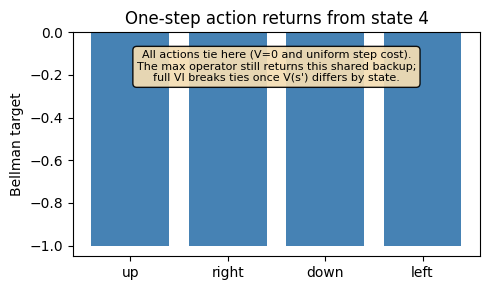


Best action value from state 4 (max over actions): -1.0
Full VI repeats this max idea for every state, every sweep.


In [2]:
# -----------------------------------------------------------------------------
# CELL: One-state Bellman warm-up (script, no def)
# Same r + gamma*V(s') computation you will see inside value_iteration, but for one state only.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BLOCK: Initialize V=0 and pick a demo state
# V=0 makes each printed target equal immediate reward (until you run full VI).
# Names `warmup_values` / `warmup_action_returns` avoid clobbering `values` for the optional recap cell below.
# -----------------------------------------------------------------------------
# Create or choose a variable used in the Bellman warm-up demo.
# Save a value in a name so the next lines can read it.
warmup_values = np.zeros(N_STATES)
# Create or choose a variable used in the Bellman warm-up demo.
state = 4  # center of 3x3

# -----------------------------------------------------------------------------
# BLOCK: Loop all actions and print each one-step Bellman target
# transition() supplies (s', r); target is the candidate backup value for that fixed action.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print(f"Inspecting state {state} before full value iteration:\n")

# Create a Python list that will store one scalar target per action.
# Save a value in a name so the next lines can read it.
warmup_action_returns = []
# Start a loop: repeat the indented block once per item in the sequence.
for action, action_name in enumerate(ACTIONS):
    # Unpack the one-step model output from transition(state, action).
    next_state, reward = transition(state, action)
    # Compute one Bellman backup candidate: reward + gamma * V(next_state).
    target = reward + GAMMA * warmup_values[next_state]
    # Add one new item to the end of a list (the list grows in place).
    warmup_action_returns.append(target)
    # Show text or numbers in the cell output area under the code.
    print(
        # Build text with {…} holes filled in by variables (an f-string).
        f"Action {action_name:>5} -> next_state={next_state}, "
        # Build text with {…} holes filled in by variables (an f-string).
        f"reward={reward:>5}, target={target:>6.2f}"
    # Close the parentheses opened earlier (end this function call / grouping).
    )

# -----------------------------------------------------------------------------
# BLOCK: Bar chart of action targets (and optional max line when it adds information)
# When targets differ across actions, a dashed line marks max (the greedy Bellman backup).
# When all targets tie (common with V=0 and uniform step cost), a horizontal line would sit on top of every bar and confuses readers—so we annotate instead.
# -----------------------------------------------------------------------------
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(5, 3))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.bar(ACTIONS, warmup_action_returns, color="steelblue")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title(f"One-step action returns from state {state}")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Bellman target")
# Assign/update a variable used later in this cell or in other cells.
best_target = max(warmup_action_returns)
# Branch: only run the next indented lines when this condition is true.
if min(warmup_action_returns) < best_target:
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.axhline(best_target, linestyle="--", color="darkred", label="max over actions (= greedy backup)")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.legend()
# Else branch: runs when the matching if/elif chain was not taken.
else:
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.annotate(
        "All actions tie here (V=0 and uniform step cost).\nThe max operator still returns this shared backup;\nfull VI breaks ties once V(s') differs by state.",
        xy=(0.5, 0.92),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.92),
    )
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# -----------------------------------------------------------------------------
# BLOCK: Read the max numerically (ties are normal early; VI later differentiates states)
# Connects the plot back to the Bellman optimality operator.
# -----------------------------------------------------------------------------
# Show text or numbers in the cell output area under the code.
print("\nBest action value from state 4 (max over actions):", best_target)
# Show text or numbers in the cell output area under the code.
print("Full VI repeats this max idea for every state, every sweep.")


## Part 2: Full Value Iteration

Now we run the full algorithm.

### Sweeps in the code below

In `value_iteration`, **one sweep** is one complete `while` iteration: the inner `for state in range(N_STATES)` visits each state, skips terminals, and applies the Bellman optimality update. After a sweep finishes, we append the largest single-state change to `deltas` and check whether the table has almost stopped moving (`delta < theta`). The convergence plot’s x-axis is the sweep index for that reason.

### What to watch for

- Do values near the goal become large and positive?
- Do values near the pit become very negative?
- Does the policy point around the pit instead of into it?

### Common misconception

Value iteration is **not** Q-learning.

- Value iteration assumes you know the transition model.
- Q-learning learns from interaction samples.

In Unit 1, value iteration is useful because it teaches planning clearly.

### Step Guide

**What this cell does:** Runs **value iteration** on the whole grid: it updates every state’s score table (`values`) sweep by sweep until it barely changes.

**How to read it (weak Python OK):** Watch two prints: the **list of `delta` per sweep** (should shrink) and the **final greedy `policy`** (arrows). The math inside the loops is the same Bellman idea as Part 1, just repeated for all states.

**What to expect in the output:** A short trace of convergence numbers, then arrays you can compare to the warm-up.

**If you feel lost:** Treat the `for` loops as “do the homework for every square on the board.” You do not need to trace every index on the first read—first notice *what gets smaller* (`delta`) and *what stabilizes* (`policy`).



State values:
  4.58   6.20   8.00
  6.20   8.00  10.00
  P     10.00   G   

Greedy policy:
 →   →   ↓ 
 →   →   ↓ 
 P   →   G 

Value iteration converged in 5 sweeps.
Final Bellman update size: 0.0

Summary:
- Value iteration applies the Bellman optimality update directly.
- It produces optimal state values for this small known MDP.
- A greedy policy can be extracted from those final values.
- In the next notebook, you move from planning in a known model to working with Gym environments.


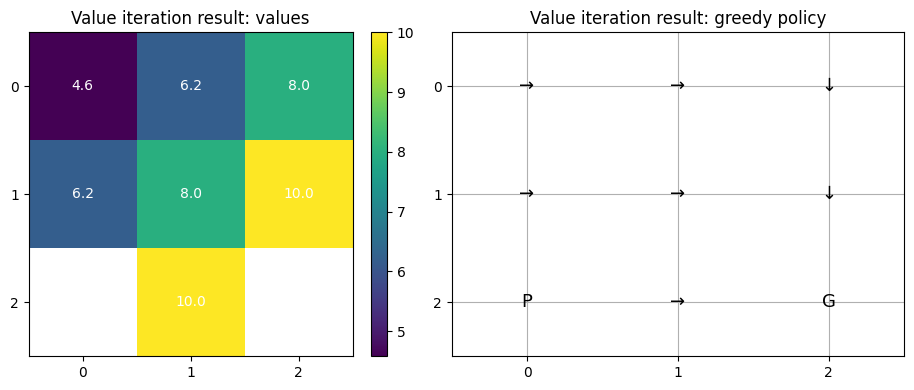

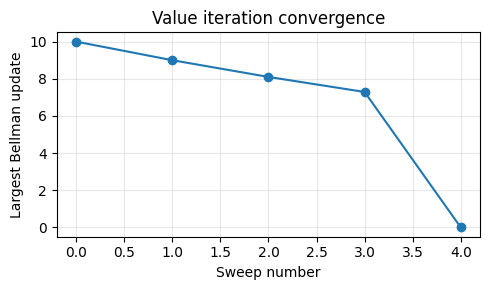

In [3]:
# -----------------------------------------------------------------------------
# CELL: Value iteration + greedy extraction + driver prints/plots
# Defines the planning functions, then runs them end-to-end.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# FUNCTION: value_iteration(gamma, theta)
# Synchronous sweeps: read old V, write new V for all states, repeat until updates are tiny.
# deltas records the largest |change| per sweep (used by plot_deltas).
# -----------------------------------------------------------------------------
# Function `value_iteration` (what it does): Run synchronous value iteration until max delta < theta; return (V, deltas).
def value_iteration(gamma=GAMMA, theta=1e-6):
    """Run synchronous value iteration until max delta < theta; return (V, deltas)."""
    # Create or choose a variable used in the Bellman warm-up demo.
    values = np.zeros(N_STATES)
    # Append or initialize the per-sweep convergence trace list.
    deltas = []

    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # Track how much the value table moved during the current sweep (or max change).
        delta = 0.0
        # Hold the updated V table for this sweep before swapping it into values.
        new_values = values.copy()
        # Start a loop: repeat the indented block once per item in the sequence.
        for state in range(N_STATES):
            # If the condition is True, run the indented block under this line.
            if state in TERMINAL_STATES:
                # Skip to the next lap of the loop (ignore the rest of this lap).
                continue
            # Create a Python list that will store one scalar target per action.
            action_returns = []
            # Start a loop: repeat the indented block once per item in the sequence.
            for action in range(len(ACTIONS)):
                # Unpack the one-step model output from transition(state, action).
                next_state, reward = transition(state, action)
                # Add one new item to the end of a list (the list grows in place).
                action_returns.append(reward + gamma * values[next_state])
            # Take the Bellman optimality max over the per-action backup list.
            best_value = max(action_returns)
            # Track how much the value table moved during the current sweep (or max change).
            delta = max(delta, abs(best_value - values[state]))
            # Hold the updated V table for this sweep before swapping it into values.
            new_values[state] = best_value
        # Create or choose a variable used in the Bellman warm-up demo.
        values = new_values
        # Add one new item to the end of a list (the list grows in place).
        deltas.append(delta)
        # If the condition is True, run the indented block under this line.
        if delta < theta:
            # Stop the loop completely and continue after the loop block.
            break

    # Send a value back to whoever called this function.
    return values, deltas

# -----------------------------------------------------------------------------
# FUNCTION: greedy_policy_from_values(values, gamma)
# Argmax of the same one-step returns: turns converged V into a deterministic greedy policy.
# -----------------------------------------------------------------------------
# Function `greedy_policy_from_values` (what it does): Extract a deterministic greedy policy by argmax over one-step Bellman targets.
def greedy_policy_from_values(values, gamma=GAMMA):
    """Extract a deterministic greedy policy by argmax over one-step Bellman targets."""
    # Create or update the greedy policy array (one int action id per state).
    policy = np.zeros(N_STATES, dtype=int)
    # Start a loop: repeat the indented block once per item in the sequence.
    for state in range(N_STATES):
        # If the condition is True, run the indented block under this line.
        if state in TERMINAL_STATES:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Create a Python list that will store one scalar target per action.
        action_returns = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for action in range(len(ACTIONS)):
            # Unpack the one-step model output from transition(state, action).
            next_state, reward = transition(state, action)
            # Add one new item to the end of a list (the list grows in place).
            action_returns.append(reward + gamma * values[next_state])
        # Create or update the greedy policy array (one int action id per state).
        policy[state] = int(np.argmax(action_returns))
    # Send a value back to whoever called this function.
    return policy

# -----------------------------------------------------------------------------
# BLOCK: Run planning, print tables, print short summary, show figures
# Driver: no new math here—just calls the functions defined above and reuses plotting helpers.
# -----------------------------------------------------------------------------
# Store the planning outputs from running value_iteration / greedy extraction.
optimal_values, deltas = value_iteration()
# Store the planning outputs from running value_iteration / greedy extraction.
optimal_policy = greedy_policy_from_values(optimal_values)

# Expose the converged table as `values` so the optional recap cell does not pick stale warm-up globals.
# Create or choose a variable used in the Bellman warm-up demo.
values = optimal_values

# Execute: print_values(optimal_values)
print_values(optimal_values)
# Execute: print_policy(optimal_policy)
print_policy(optimal_policy)
# Show text or numbers in the cell output area under the code.
print(f"\nValue iteration converged in {len(deltas)} sweeps.")
# Show text or numbers in the cell output area under the code.
print("Final Bellman update size:", deltas[-1])

# Show text or numbers in the cell output area under the code.
print("\nSummary:")
# Show text or numbers in the cell output area under the code.
print("- Value iteration applies the Bellman optimality update directly.")
# Show text or numbers in the cell output area under the code.
print("- It produces optimal state values for this small known MDP.")
# Show text or numbers in the cell output area under the code.
print("- A greedy policy can be extracted from those final values.")
# Show text or numbers in the cell output area under the code.
print("- In the next notebook, you move from planning in a known model to working with Gym environments.")

# Save a value in a name so the next lines can read it.
plot_values_and_policy(optimal_values, optimal_policy, title="Value iteration result")
# Execute: plot_deltas(deltas)
plot_deltas(deltas)


### Step Guide

**What this cell does:** Tries to draw a **simple recap figure** from numbers that already exist in the notebook (values, deltas, etc.).

**How to read it (weak Python OK):** If a plot appears, read it like a poster: *left vs right*, *darker vs brighter*, *labels on the axes*. If no plot appears, the cell still “passed”—it only means no friendly numeric object was found to chart.

**What to expect in the output:** One or two plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Use this cell as a **second pass** after you understand Parts 1–2. Charts are memory aids, not a substitute for the printed tables above.


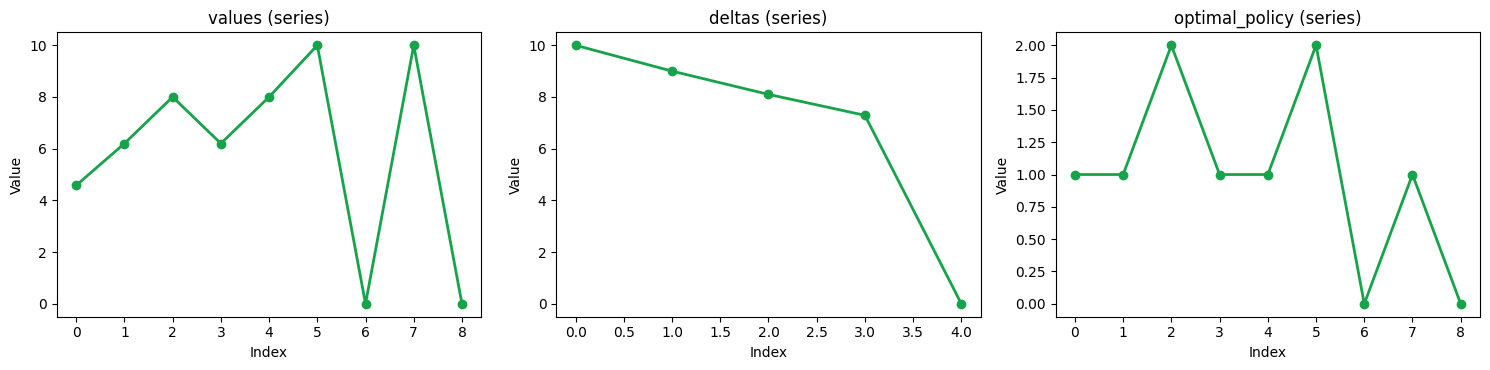

In [4]:
# -----------------------------------------------------------------------------
# CELL: Optional auto-visual recap (generic scanner)
# Looks for small numeric variables in globals() and plots up to three; else a tiny summary.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BLOCK: Imports
# `numbers` is included for consistency with other course notebooks using numeric checks.
# -----------------------------------------------------------------------------
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Import a Python module into this notebook kernel namespace.
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# FUNCTION: _is_number(value)
# Scalar numeric check; rejects bool because bool is a subclass of int in Python.
# -----------------------------------------------------------------------------
# Function `_is_number` (what it does): True for real numeric scalars; rejects bool even though bool subclasses int.
def _is_number(value):
    """True for real numeric scalars; rejects bool even though bool subclasses int."""
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# -----------------------------------------------------------------------------
# FUNCTION: _as_numeric_dict(value)
# Returns (labels, values) for a bar chart only if the dict is small and all-numeric.
# -----------------------------------------------------------------------------
# Function `_as_numeric_dict` (what it does): If dict is small and all values numeric, return (labels, array) for a bar chart; else None.
def _as_numeric_dict(value):
    """If dict is small and all values numeric, return (labels, array) for a bar chart; else None."""
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# -----------------------------------------------------------------------------
# FUNCTION: _as_numeric_array(value, dims)
# Safe coercion to float ndarray with rank and size caps (keeps recap plots lightweight).
# -----------------------------------------------------------------------------
# Function `_as_numeric_array` (what it does): Coerce value to a rank-`dims` float ndarray with safe size caps; return None on failure.
def _as_numeric_array(value, dims):
    """Coerce value to a rank-`dims` float ndarray with safe size caps; return None on failure."""
    # Try/except: catch conversion failures without crashing the recap cell.
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except: catch conversion failures without crashing the recap cell.
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# -----------------------------------------------------------------------------
# BLOCK: Build search order (preferred names, then sorted globals)
# Tries common RL variable names first, then scans the rest of the global namespace.
# -----------------------------------------------------------------------------
# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "optimal_values", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# -----------------------------------------------------------------------------
# BLOCK: Scan globals and collect up to three plottable objects
# Priority order inside the loop: dict chart, else heatmap, else 1D line series.
# -----------------------------------------------------------------------------
# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# -----------------------------------------------------------------------------
# BLOCK: Render either fallback summary or the discovered plots
# If nothing matched, show a coarse object-count summary instead of failing silently.
# -----------------------------------------------------------------------------
# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Value iteration works by repeatedly asking: what is the best possible return from this state if I act optimally now?

**If students remember one idea:** The Bellman optimality update is the engine of value iteration and the foundation of many later RL methods.

**Quick check before moving on:**
- Can you explain why value iteration uses a max over actions?
- Can you extract the policy idea from the learned state values?

**Bridge to the next step:** After learning how to solve small MDPs exactly, you are ready to work with interactive RL environments.

**For weaker coders:** If the loops still feel fuzzy, re-run Part 1 only and write on paper one row: *state → best action → reward + next state*. That single row is the same idea the loops automate in Part 2.
